In [21]:
print("\nCARACTERÍSTICAS DETALHADAS POR CLUSTER:")
for cluster in sorted(df['Cluster'].unique()):
    print(f"\n👉 CLUSTER {cluster}:")
    cluster_data = df[df['Cluster'] == cluster]
    
    # Estatísticas numéricas
    print("\nEstatísticas num médias:")
    print(cluster_data[['Age', 'Debt', 'YearsEmployed', 'CreditScore', 'Income']].mean())
    
    # Variáveis categóricas mais frequentes
    print("\nProfissões mais comuns:")
    print(cluster_data['Industry'].value_counts(normalize=True).head(3))
    
    print("\nCEPs mais frequentes:")
    print(cluster_data['ZipCode'].value_counts().head(3))
    
    print("\nTaxa de aprovação:")
    print(cluster_data['Approved'].value_counts(normalize=True))
    
    print("\nEstado civil predominante:")
    print(cluster_data['Married'].value_counts(normalize=True))


CARACTERÍSTICAS DETALHADAS POR CLUSTER:

👉 CLUSTER 0:

Estatísticas num médias:
Age               24.498309
Debt              11.061066
YearsEmployed      1.506176
CreditScore        2.227941
Income           847.529412
dtype: float64

Profissões mais comuns:
Industry
Energy             0.176471
Materials          0.154412
ConsumerStaples    0.132353
Name: proportion, dtype: float64

CEPs mais frequentes:
ZipCode
0      31
120    14
80     13
Name: count, dtype: int64

Taxa de aprovação:
Approved
1    0.5
0    0.5
Name: proportion, dtype: float64

Estado civil predominante:
Married
1    0.779412
0    0.220588
Name: proportion, dtype: float64

👉 CLUSTER 1:

Estatísticas num médias:
Age               29.983268
Debt               1.983617
YearsEmployed      1.300523
CreditScore        1.315904
Income           655.851852
dtype: float64

Profissões mais comuns:
Industry
Energy                   0.226580
ConsumerDiscretionary    0.100218
Industrials              0.095861
Name: proportion, 

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Carregar e preparar os dados
df = pd.read_csv('./data/credito.csv')
features = df[['Age', 'Debt', 'YearsEmployed', 'CreditScore', 'Income']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# 2. Aplicar K-Means com 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)

# 3. Análise descritiva por cluster
print("\nESTATÍSTICAS BÁSICAS POR CLUSTER:")
cluster_stats = df.groupby('Cluster')[['Age', 'Debt', 'YearsEmployed', 'CreditScore', 'Income']].mean()
print(cluster_stats)

# 4. Distribuição de variáveis categóricas por cluster
def plot_categorical_distribution(col, top_n=5):
    plt.figure(figsize=(10, 5))
    cluster_crosstab = pd.crosstab(df['Cluster'], df[col], normalize='index')
    cluster_crosstab.T.sort_values(by=[0,1,2,3], ascending=False).head(top_n).T.plot(kind='bar', stacked=True)
    plt.title(f'Distribuição de {col} por Cluster')
    plt.ylabel('Proporção')
    plt.legend(title=col, bbox_to_anchor=(1.05, 1))
    plt.show()

print("\nDISTRIBUIÇÃO DE PROFISSÕES POR CLUSTER:")
plot_categorical_distribution('Industry')

print("\nDISTRIBUIÇÃO DE CEPs POR CLUSTER:")
plot_categorical_distribution('ZipCode')

print("\nTAXA DE APROVAÇÃO POR CLUSTER:")
print(pd.crosstab(df['Cluster'], df['Approved'], normalize='index'))

# 5. Visualização das características dos clusters
plt.figure(figsize=(12, 8))
for i, col in enumerate(['Age', 'Debt', 'YearsEmployed', 'CreditScore', 'Income'], 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='Cluster', y=col, data=df)
    plt.title(f'Distribuição de {col} por Cluster')
plt.tight_layout()
plt.show()

# 6. Análise detalhada por cluster
print("\nCARACTERÍSTICAS DETALHADAS POR CLUSTER:")
for cluster in sorted(df['Cluster'].unique()):
    print(f"\n👉 CLUSTER {cluster}:")
    cluster_data = df[df['Cluster'] == cluster]
    
    # Estatísticas numéricas
    print("\nEstatísticas numéricas médias:")
    print(cluster_data[['Age', 'Debt', 'YearsEmployed', 'CreditScore', 'Income']].mean())
    
    # Variáveis categóricas mais frequentes
    print("\nProfissões mais comuns:")
    print(cluster_data['Industry'].value_counts(normalize=True).head(3))
    
    print("\nCEPs mais frequentes:")
    print(cluster_data['ZipCode'].value_counts().head(3))
    
    print("\nTaxa de aprovação:")
    print(cluster_data['Approved'].value_counts(normalize=True))
    
    print("\nEstado civil predominante:")
    print(cluster_data['Married'].value_counts(normalize=True))

ModuleNotFoundError: No module named 'seaborn'

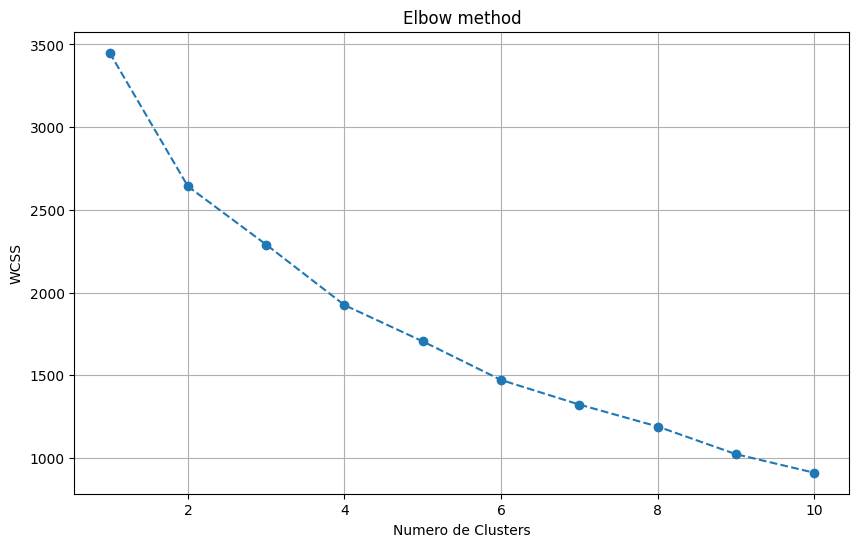

In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow method')
plt.xlabel('Numero de Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

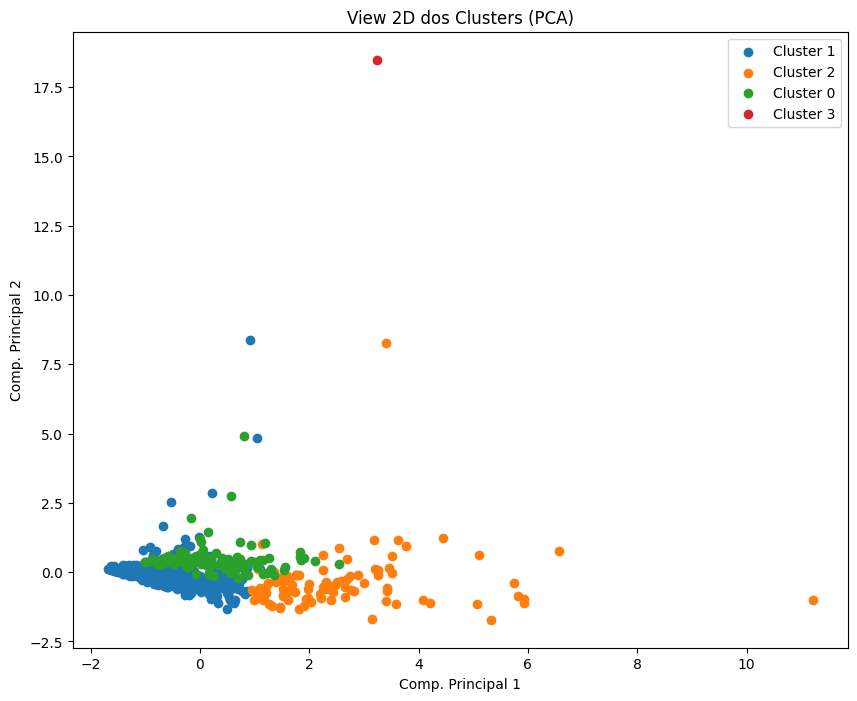

In [16]:
plt.figure(figsize=(10,8))
for cluster in pca_df['Cluster'].unique():
    plt.scatter(pca_df[pca_df['Cluster']==cluster]['PC1'], 
                pca_df[pca_df['Cluster']==cluster]['PC2'], 
                label=f'Cluster {cluster}')

plt.title('View 2D dos Clusters (PCA)')
plt.xlabel('Comp. Principal 1')
plt.ylabel('Comp. Principal 2')
plt.legend()
plt.show()

In [15]:
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters

In [14]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features)

In [13]:
from sklearn.decomposition import PCA

In [12]:
print(df.groupby('Cluster')['Ethnicity'].value_counts(normalize=True).head(16))

Cluster  Ethnicity
0        White        0.625000
         Black        0.235294
         Latino       0.058824
         Asian        0.051471
         Other        0.029412
1        White        0.629630
         Black        0.165577
         Asian        0.087146
         Latino       0.082789
         Other        0.034858
2        White        0.361702
         Black        0.319149
         Asian        0.127660
         Latino       0.117021
         Other        0.074468
3        Other        1.000000
Name: proportion, dtype: float64


In [11]:
print(df.groupby('Cluster')['Approved'].value_counts(normalize=True))
print(df.groupby('Cluster')['Industry'].value_counts(normalize=True).head(16))

Cluster  Approved
0        0           0.500000
         1           0.500000
1        0           0.647059
         1           0.352941
2        1           0.808511
         0           0.191489
3        1           1.000000
Name: proportion, dtype: float64
Cluster  Industry             
0        Energy                   0.176471
         Materials                0.154412
         ConsumerStaples          0.132353
         Industrials              0.095588
         Utilities                0.088235
         Financials               0.066176
         Healthcare               0.058824
         ConsumerDiscretionary    0.051471
         InformationTechnology    0.051471
         Real Estate              0.051471
         Education                0.044118
         CommunicationServices    0.022059
         Research                 0.007353
1        Energy                   0.226580
         ConsumerDiscretionary    0.100218
         Industrials              0.095861
Name: proportion, dt

In [10]:
cluster_stats = df.groupby('Cluster')[['Age', 'Debt', 'YearsEmployed', 'CreditScore', 'Income']].mean()
print(cluster_stats)

               Age       Debt  YearsEmployed  CreditScore         Income
Cluster                                                                 
0        24.498309  11.061066       1.506176     2.227941     847.529412
1        29.983268   1.983617       1.300523     1.315904     655.851852
2        49.288830   9.007819       7.791170     7.968085    1975.489362
3        17.500000  22.000000       0.000000     0.000000  100000.000000


In [9]:
df['Cluster'] = clusters

In [8]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(scaled_features)

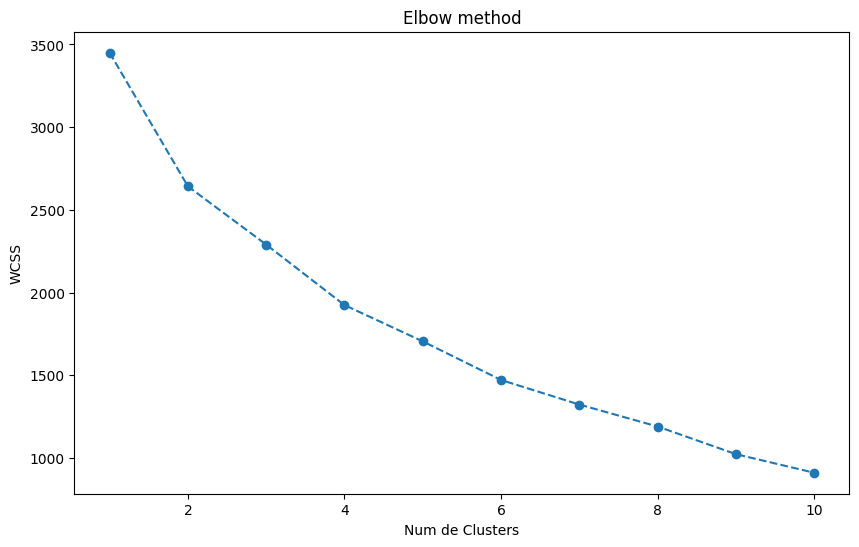

In [7]:
plt.figure(figsize=(10,6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow method')
plt.xlabel('Num de Clusters')
plt.ylabel('WCSS')
plt.show()

In [5]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

In [4]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [3]:
features = df[['Age', 'Debt', 'YearsEmployed', 'CreditScore', 'Income']]

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
df = pd.read_csv ('./data/credito.csv')